# Projet de classification d'image de cellules afin de détecter le parasite de la Malaria
### Import de tous les modules nécessaires au workflow

In [2]:
import numpy as np 
import matplotlib.pyplot as plt 
from PIL import Image
import os
%reload_ext autoreload
%autoreload 2
import Partie_1_Pre_Traitement as pre_traitement
import Partie_2_MLP as mlp
import Partie_3_Evaluation as eval
import affichages as aff

## I. Chargement des données
### Import du dataset

In [9]:
data, target = mlp.load_images(
    uninfected_dir="Uninfected",
    parasitized_dir="Parasitized",
    image_size=(32,32),
    max_per_class=1000
)

print(f"Les dimensions du dataset sont : {data.shape}")


Les dimensions du dataset sont : (2000, 1032)


### Visualisation de quelque images

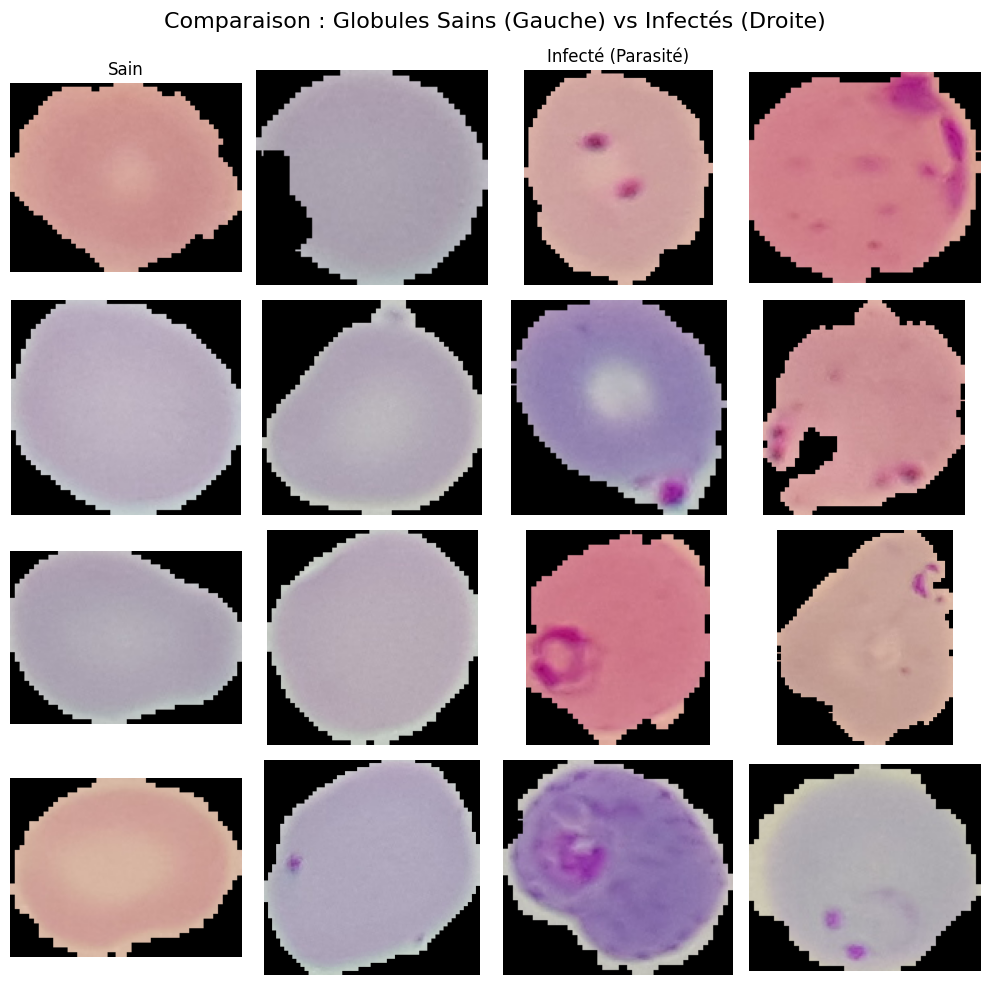

In [10]:
UNINFECTED_PATH = r"Uninfected"
PARASITIZED_PATH = r"Parasitized"

aff.plot_image_grid(UNINFECTED_PATH, PARASITIZED_PATH)

## II. Modèle MLP avec mini-Batch
### Recherche des meilleurs hyperparamètres pour le réseau

In [ ]:
best, results = mlp.random_search_hyperparameters(
    data,
    target,
    train_func=mlp.mlp_fit_minibatch,
    predict_func=mlp.predict_relu,
    hidden_layer_configs=[[32, 16], [64, 32], [128, 64]],
    batch_sizes=[16, 32, 64],
    n_trials=10
)


TRIAL 1/10
hidden_layers : [32, 16]
batch_size    : 64
learning_rate : 0.005567
--- Fold 1/3 ---
Accuracy fold 1 : 0.7391 | Loss : 0.4442
--- Fold 2/3 ---
Accuracy fold 2 : 0.7346 | Loss : 0.3955
--- Fold 3/3 ---
Accuracy fold 3 : 0.7282 | Loss : 0.4230

Accuracy moyenne : 0.7340
â†’ accuracy = 0.7340

TRIAL 2/10
hidden_layers : [64, 32]
batch_size    : 64
learning_rate : 0.015304
--- Fold 1/3 ---
Accuracy fold 1 : 0.7871 | Loss : 0.2409
--- Fold 2/3 ---
Accuracy fold 2 : 0.7916 | Loss : 0.2110
--- Fold 3/3 ---
Accuracy fold 3 : 0.7417 | Loss : 0.2371

Accuracy moyenne : 0.7735
â†’ accuracy = 0.7735

TRIAL 3/10
hidden_layers : [32, 16]
batch_size    : 16
learning_rate : 0.045452
--- Fold 1/3 ---
Accuracy fold 1 : 0.7976 | Loss : 0.0697
--- Fold 2/3 ---
    -> Early Stopping à l'époque 55 (Loss opt: 0.0697)
Accuracy fold 2 : 0.7541 | Loss : 3.6442
--- Fold 3/3 ---
Accuracy fold 3 : 0.7688 | Loss : 0.2188

Accuracy moyenne : 0.7735
â†’ accuracy = 0.7735

TRIAL 4/10
hidden_layers : [128,

In [ ]:
best_lr_minibatch = best["learning_rate"]
best_hidden_layers_minibatch = best["hidden_layers"]
best_batch_size_minibatch = best["batch_size"]

modele_minibatch = mlp.cross_validation(data, target, mlp.mlp_fit_minibatch, mlp.predict_relu, n_folds=5, learning_rate=best_lr_minibatch, hidden_layer_sizes=best_hidden_layers_minibatch, batch_size=best_batch_size_minibatch)

--- Fold 1/5 ---
Accuracy fold 1 : 0.8250 | Loss : 0.0327
--- Fold 2/5 ---
Accuracy fold 2 : 0.7700 | Loss : 0.0447
--- Fold 3/5 ---
Accuracy fold 3 : 0.8000 | Loss : 0.0350
--- Fold 4/5 ---
Accuracy fold 4 : 0.7750 | Loss : 0.0339
--- Fold 5/5 ---
Accuracy fold 5 : 0.7950 | Loss : 0.0305

Accuracy moyenne : 0.7930


## III. Résultats et exploitation